The objective of this notebook is to understand the characteristics of customers who are likely to churn. By exploring the relationships between customer demographics, services, billing information, and churn behavior, we aim to identify patterns that can guide feature engineering and help the business design effective retention strategies.

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
# Identify categorical and numerical columns

categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(categorical_cols)
print(numerical_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']
['SeniorCitizen', 'tenure', 'MonthlyCharges']


/var/folders/hs/5tjjygrd7_xd6q2cfnmr5hlm0000gn/T/ipykernel_33031/3352500499.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


Univariate Analysis

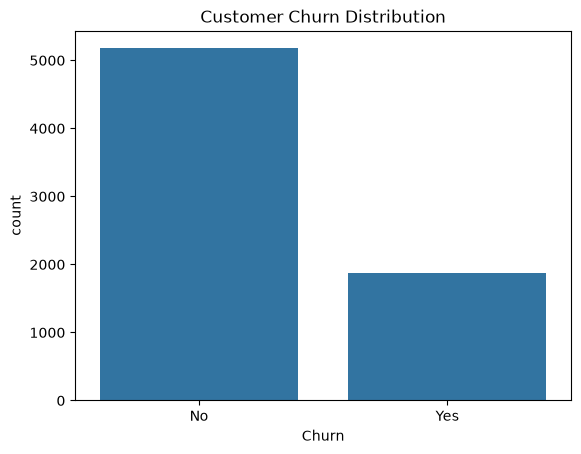

In [ ]:
# Target Distribution

sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

As visible from the plot, churn is not very common however the dataset is imbalanced

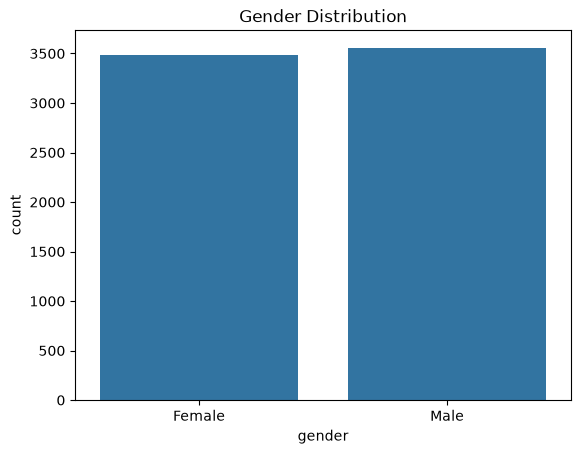

In [7]:
# Gender Distribution

sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

Plot shows thaat customer base is not dominated by any specific gender 

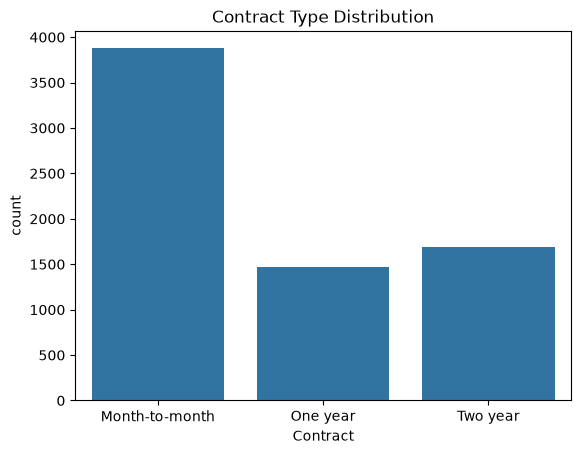

In [8]:
# Contract type 

sns.countplot(data=df, x="Contract")
plt.title("Contract Type Distribution")
plt.show()

Month to month contract type is most dominant followed by two-year contract and lastly one year contract

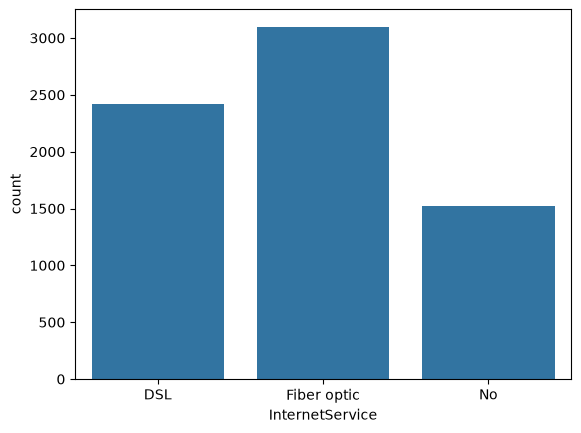

In [9]:
# Internet Service

sns.countplot(data=df, x="InternetService")
plt.show()

From the plot we can infer that Fiber optic appears to be the most commonly used internet service among customers in this dataset.

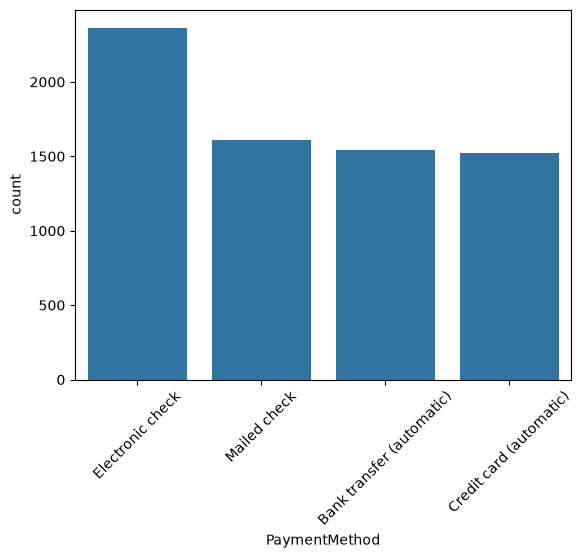

In [10]:
# Payment Method

sns.countplot(data=df,x="PaymentMethod")
plt.xticks(rotation=45)
plt.show()

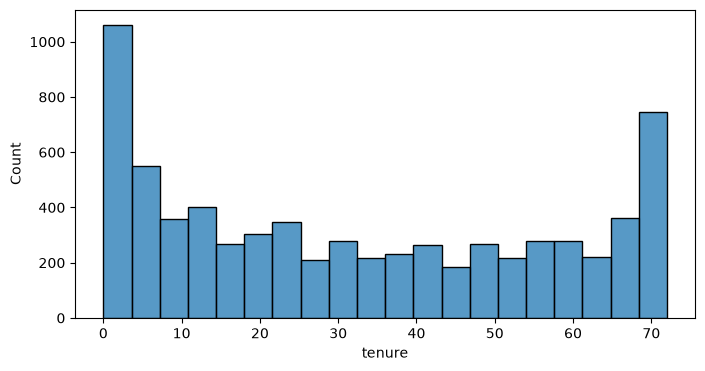

In [11]:
# Tenure 

plt.figure(figsize=(8,4))
sns.histplot(df["tenure"], bins=20)
plt.show()

Customers tend to leave early within the first 5 years, however there are some customers who tend to stay over a tenure of 70

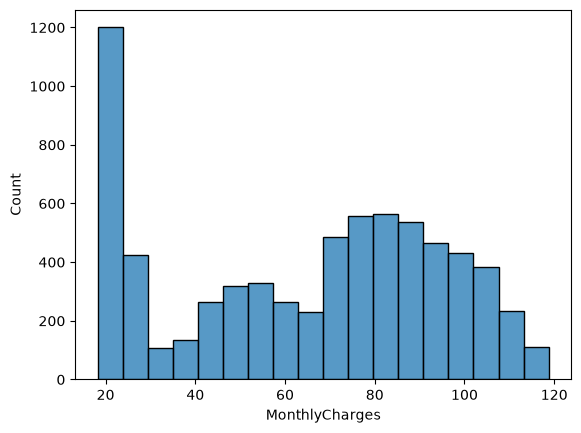

In [12]:
# Monthly Charges

sns.histplot(df["MonthlyCharges"])
plt.show()

Monthly charges are highly concentrated in the range of 20-25 

Bivariate Analysis

Which factors influence churn ?

<Axes: xlabel='gender', ylabel='count'>

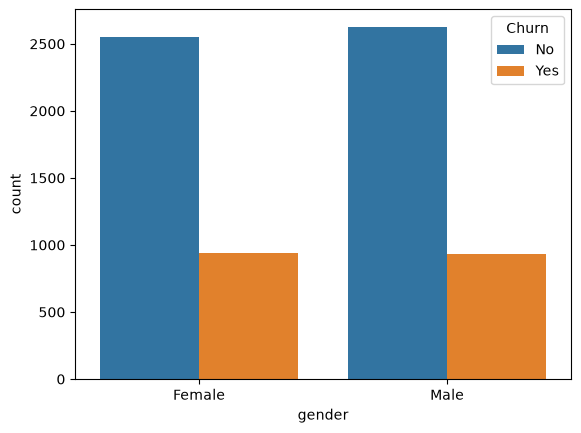

In [13]:
# Gender

sns.countplot(data=df,
              x="gender",
              hue="Churn")

<Axes: xlabel='Contract', ylabel='count'>

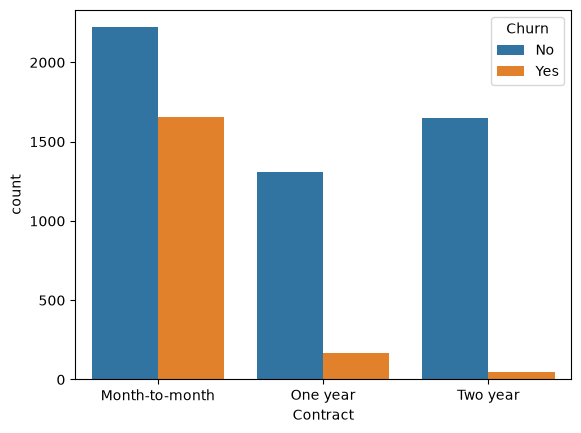

In [14]:
# Contract type 

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

We can infer that Month-to-month customers churn much more.The business could reduce churn by incentivizing customers to switch to longer-term contracts through discounts or loyalty programs.

<Axes: xlabel='Churn', ylabel='tenure'>

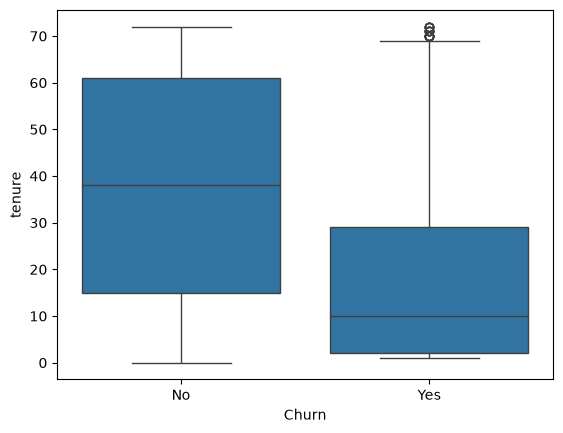

In [ ]:
# tenure 

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

Customers who leave early have lower tenure suggesting that encouraging customers for long tenure by incentivizing them is beneficial 

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

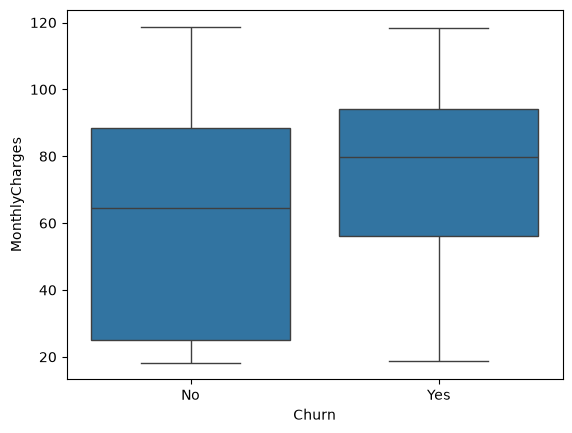

In [16]:
# monthly charges

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

Expensive plans have higher probability of churning thus its better to pull customers for lower charges plans so they can retain for ln=ong time

<Axes: xlabel='InternetService', ylabel='count'>

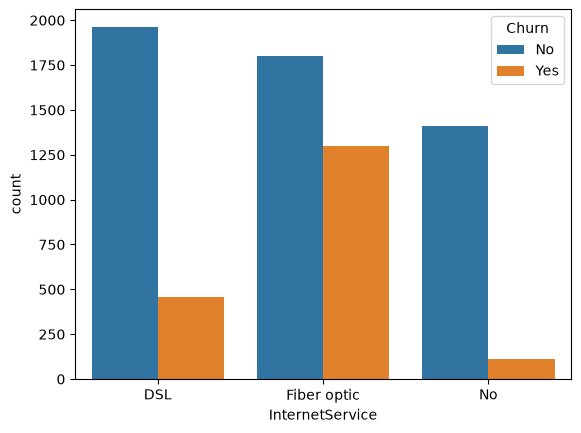

In [17]:
# Internet Service

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

Althought, fiber optic has higher overall customers but it also have relatively higher churn rates compared to DSL or customers who don't have internet service

<Axes: xlabel='TechSupport', ylabel='count'>

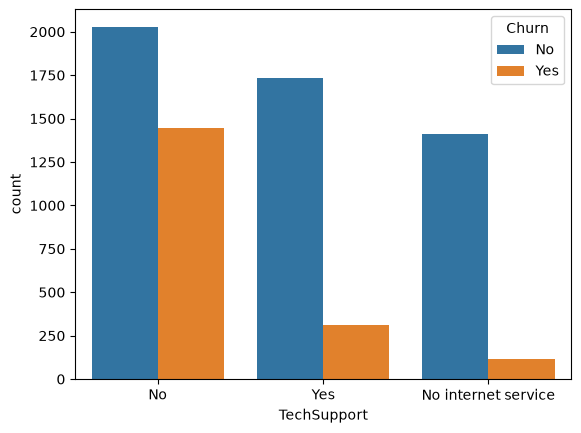

In [18]:
# tech support

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

Customers who do not subscribe to Tech Support exhibit noticeably higher churn than customers who do.
Providing discounted technical support or bundling it with selected plans may improve customer retention.